# Examples of visualization of BST egg transfer calculations

In [1]:
%matplotlib inline

import os
from glob import glob
from datetime import timedelta, datetime
import numpy as np
import pandas as pd
import xarray as xr

from scipy.spatial import KDTree
import geopy.distance
import parcels
from IPython.display import HTML

import math
import warnings
warnings.filterwarnings("ignore")

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.patches import ConnectionPatch

mpl.rcParams['animation.embed_limit'] = 2**128
plt.rcParams.update({'figure.dpi':170,'savefig.dpi':300,'savefig.bbox':'tight'})
from matplotlib import colors
import cmocean.cm as cm

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


LAND = cfeature.NaturalEarthFeature(
    category='physical', 
    name='land', 
    scale='10m',
    edgecolor='face',
    facecolor=cfeature.COLORS['land']
)

def make_map(ax, bbox, projection=ccrs.PlateCarree()):
    ax.set_extent(bbox, crs=projection)
    ax.add_feature(LAND, zorder=5, facecolor='lightgray')
    ax.coastlines(resolution='10m', linewidth=0.8, zorder=5)
    gl = ax.gridlines(draw_labels=True,
                  linewidth=0.5, color='black', alpha=0.7, linestyle='--')
    gl.top_labels = gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    return ax

## Trajectories info

In [2]:
filename = 'Output/Trajectories_2001.nc'
ds = xr.open_dataset(filename)
ds

<xarray.Dataset> Size: 494MB
Dimensions:      (parcels: 15580, timesteps: 720)
Coordinates:
  * timesteps    (timesteps) int64 6kB 1 2 3 4 5 6 7 ... 715 716 717 718 719 720
  * parcels      (parcels) int64 125kB 1 2 3 4 5 ... 15577 15578 15579 15580
Data variables:
    temperature  (parcels, timesteps) float32 45MB ...
    latitude     (parcels, timesteps) float64 90MB ...
    longitude    (parcels, timesteps) float64 90MB ...
    depth        (parcels, timesteps) float64 90MB ...
    time         (parcels, timesteps) datetime64[ns] 90MB ...
    on_land      (parcels, timesteps) float64 90MB ...
Attributes:
    title:         OceanParcels simulation
    description:   This dataset contains information about trajectories of pa...
    creator:       Dmitriy Krasilnikov
    date_created:  2025-11-21 19:24:25
    contact:       krasilnikov.dmitrij@inbox.ru
    institution:   MHI RAS
    source:        Generated for science purposes

In [3]:
time = np.array(ds['time'][:])
lat = np.array(ds['latitude'][:])
lon = np.array(ds['longitude'][:])
z = np.array(ds['depth'][:])
temp = np.array(ds['temperature'][:])
if 'ds' in globals():
    del ds

### Animation

In [ ]:
%%capture

# Time interval to plot
# outputdt = timedelta(days=1)
outputdt = timedelta(hours=24)
# timerange in nanoseconds
timerange = np.arange(
    np.nanmin(time),
    np.nanmax(time) + np.timedelta64(outputdt),
    outputdt,
)
# bbox
xm = np.nanmin(lon) - 1
xM = np.nanmax(lon) + 1
ym = np.nanmin(lat) - 1
yM = np.nanmax(lat) + 1
bbox = [xm,xM, ym,yM]


fig, axs = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True, 
                        figsize=(11, 6), subplot_kw=dict(projection=ccrs.Mercator()))
ax = make_map(axs, bbox=bbox)

time_id = np.where(time == timerange[0])

title = ax.set_title(f"Particles at t: {str(timerange[0])[:16]}")

scatter = ax.scatter(lon[time_id], lat[time_id], c=temp[time_id],
                    s=40, 
                    cmap = cm.thermal,
                    vmin=np.nanmin(temp), 
                    vmax=np.nanmax(temp),  
                    edgecolors='None', transform=ccrs.Geodetic())

# fig.colorbar(scatter)

fig.colorbar(scatter, orientation='vertical', label='Temperature, deg. C')

# ax.coastlines()
ax.gridlines()

def animate(i):
    title.set_text(f"Particles at t: {str(timerange[i])[:16]}")

    time_id = np.where(time == timerange[i])
    scatter.set_offsets(
        np.c_[lon[time_id], lat[time_id]])
    scatter.set_array(temp[time_id])

# mpl.rcParams['animation.embed_limit'] = 2**128
anim = FuncAnimation(fig, animate, frames=len(timerange), interval=500)
anim.save(f'Parcels_temp.mp4')

### Start and finish

In [5]:
start_date = np.datetime64(f'2001-04-01T12:00')
end_date = np.datetime64(f'2001-04-14T12:00')

particles_starting_on_date = []
starting_moment = []
finish_moment = []


for row_index in range(time.shape[0]):
    not_nan_indices = np.where(~np.isnan(lon[row_index]))[0]
    if len(not_nan_indices) > 0:
        first = not_nan_indices[0]
        if time[row_index, first] == start_date:
            particles_starting_on_date.append(row_index)
            starting_moment = first
            finish_moment.append(not_nan_indices[-1])
            
particles_starting_on_date = np.array(particles_starting_on_date)
starting_moment = np.array(starting_moment)
finish_moment = np.array(finish_moment)

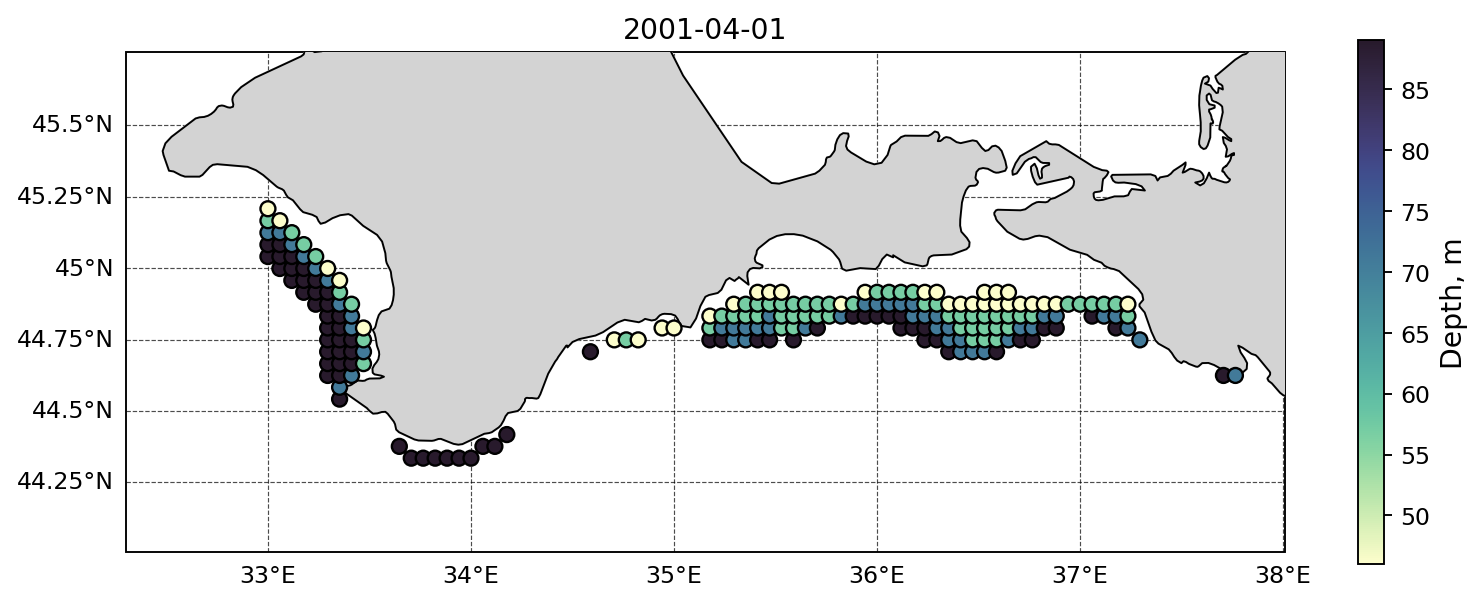

In [6]:
# timestep=0
lon_start = lon[particles_starting_on_date, starting_moment]
lat_start = lat[particles_starting_on_date, starting_moment]
z_start = z[particles_starting_on_date, starting_moment]

bbox = [32.3, 38.01, 44, 45.75]

fig, axs = plt.subplots(figsize=(11, 4), subplot_kw=dict(projection=ccrs.Mercator()))
ax = make_map(axs, bbox)

scatter = ax.scatter(
    lon_start, lat_start, c=z_start,
    s=40,
    cmap=cm.deep,
    vmin=np.nanmin(z_start),
    vmax=np.nanmax(z_start),
    edgecolors='black',
    transform=ccrs.Geodetic(),
    zorder = 5,
)

ax.set_title(f"{str(start_date)[:-6]}")

cbar = fig.colorbar(scatter, orientation='vertical')
cbar.set_label(label='Depth, m', size = 12)

# ax.gridlines()
plt.show()


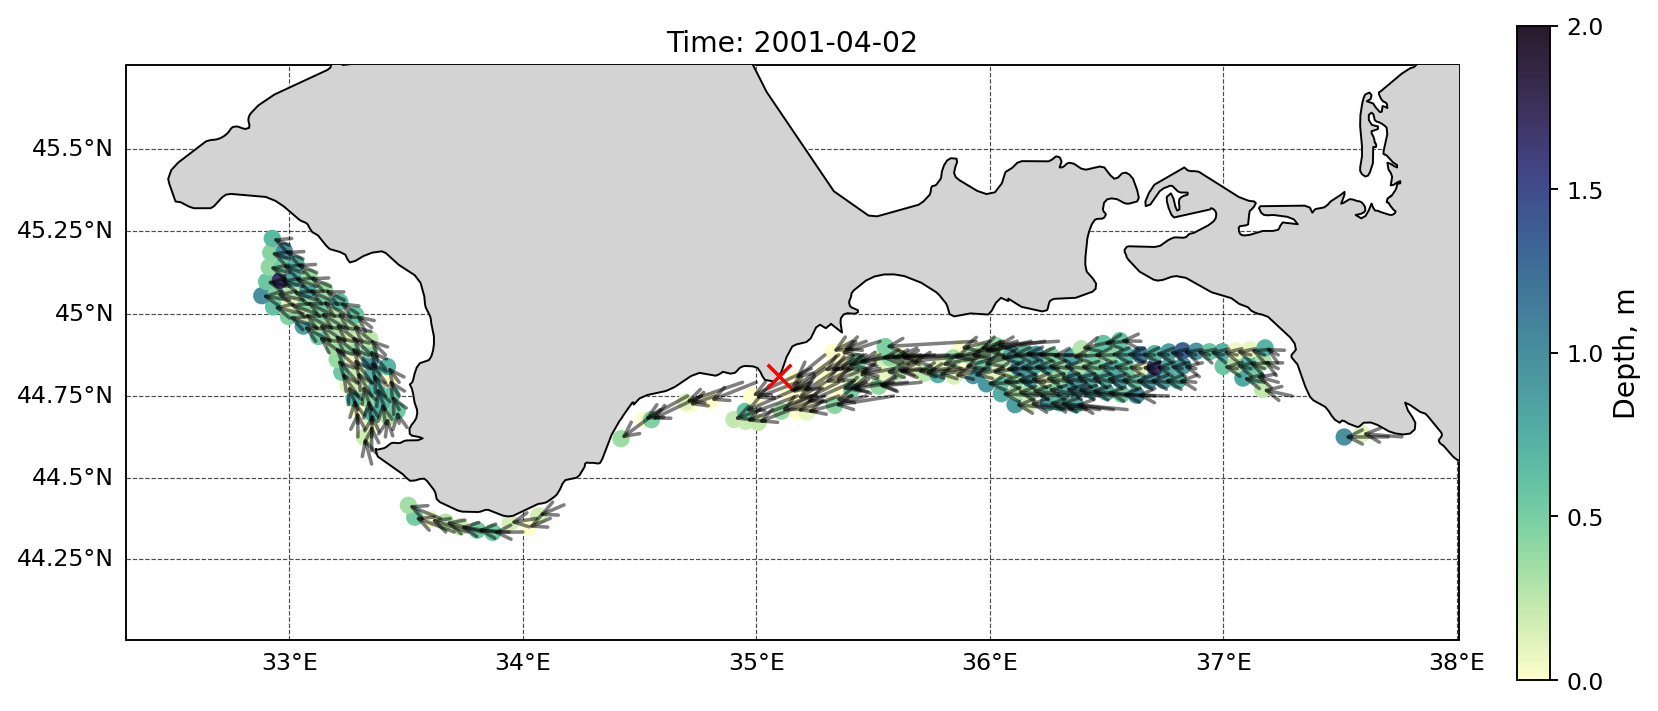

In [7]:
bbox = [32.3, 38.01, 44, 45.75]
vmin = 0
vmax = 2

# time shift between moments
n1 = 0 # launch
n2 = 8 # finish

# n1 = 8
# n2 = 56

lon1 = lon[particles_starting_on_date, starting_moment + n1]
lat1 = lat[particles_starting_on_date, starting_moment + n1]
z1 = z[particles_starting_on_date, starting_moment + n1]

lon2 = lon[particles_starting_on_date, starting_moment + n2]
lat2 = lat[particles_starting_on_date, starting_moment + n2]
z2 = z[particles_starting_on_date, starting_moment + n2]

fig, axs = plt.subplots(figsize=(11, 5), subplot_kw=dict(projection=ccrs.Mercator()))
ax = make_map(axs, bbox)

scatter = ax.scatter(
    lon2, lat2, c=z2, s=40, cmap=cm.deep,
    vmin=vmin, vmax=vmax,
    # edgecolors='black',
    transform=ccrs.Geodetic(),
    zorder=4
)
ax.set_title(f"Time: {str(time[particles_starting_on_date, starting_moment + n2][0])[:10]}")

valid_mask = finish_moment >= starting_moment+n2


lon_finish = lon[particles_starting_on_date[~valid_mask], finish_moment[~valid_mask]]
lat_finish = lat[particles_starting_on_date[~valid_mask], finish_moment[~valid_mask]]

# Добавляем стрелки со второй оси
for i, particle in enumerate(valid_mask):
    if particle == True:
        con = ConnectionPatch(
            xyA=(lon1[i], lat1[i]), coordsA=ccrs.Geodetic()._as_mpl_transform(ax),
            xyB=(lon2[i], lat2[i]), coordsB=ccrs.Geodetic()._as_mpl_transform(ax),
            # axesA=ax2, axesB=ax2,
            arrowstyle='->', mutation_scale=15, color='black', linewidth=1.5, alpha=0.5,
            zorder=5,
            )
        ax.add_artist(con)

ax.scatter(
            lon_finish, lat_finish,
            marker='x', color='red', s=100,
            transform=ccrs.Geodetic(),
            label='Missing in second time',
            zorder = 5,
        )

cbar = fig.colorbar(scatter, orientation='vertical', fraction=0.04, pad=0.04)
cbar.set_label(label='Depth, m', size=12)
ticks = np.arange(vmin, vmax + 0.1, 0.5)
cbar.set_ticks(ticks)


## Final Table

In [8]:
filename = 'Output/Start_and_Finish_2001.nc'
ds = xr.open_dataset(filename)
df = ds.to_dataframe().reset_index()
df

,index,lat_start,lon_start,time_start,depth_start,temp_start,lat_finish,lon_finish,time_finish,depth_finish,temp_finish,gastrulation,stage,why_dead
0,0,44.333336,33.705883,2001-04-01 12:00:00,89.0,7.974372,44.420175,33.392109,2001-04-03 15:00:00,0.469729,9.222212,0,0.20,low_temp_gastrulation
1,1,44.333336,33.764706,2001-04-01 12:00:00,89.0,7.991161,44.388963,33.503483,2001-04-03 15:00:00,0.216547,9.206964,0,0.20,low_temp_gastrulation
2,2,44.333336,33.823528,2001-04-01 12:00:00,89.0,7.999875,44.384160,33.554090,2001-04-03 15:00:00,0.366786,9.206964,0,0.20,low_temp_gastrulation
3,3,44.333336,33.882355,2001-04-01 12:00:00,89.0,8.016372,44.369899,33.644571,2001-04-03 15:00:00,0.293688,9.136581,0,0.20,low_temp_gastrulation
4,4,44.333336,33.941177,2001-04-01 12:00:00,89.0,8.061551,44.354738,33.704486,2001-04-03 15:00:00,0.309277,9.110874,0,0.20,low_temp_gastrulation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15234,15234,45.125004,33.058823,2001-06-15 12:00:00,71.0,7.964384,45.163814,32.978071,2001-06-17 03:00:00,1.626215,18.103558,1,0.44,low_temp_after_gastrulation
15235,15235,45.125004,33.117645,2001-06-15 12:00:00,57.0,8.098639,45.187759,33.009019,2001-06-17 03:00:00,0.891675,18.123753,1,0.45,low_temp_after_gastrulation
15236,15236,45.166672,33.000000,2001-06-15 12:00:00,57.0,8.153571,45.194953,32.897593,2001-06-18 03:00:00,0.485258,18.468096,1,0.71,low_temp_after_gastrulation
15237,15237,45.166672,33.058823,2001-06-15 12:00:00,46.0,8.365880,45.205543,33.010989,2001-06-16 09:00:00,0.379498,17.907555,1,0.24,low_temp_after_gastrulation


### Hatched larvae map

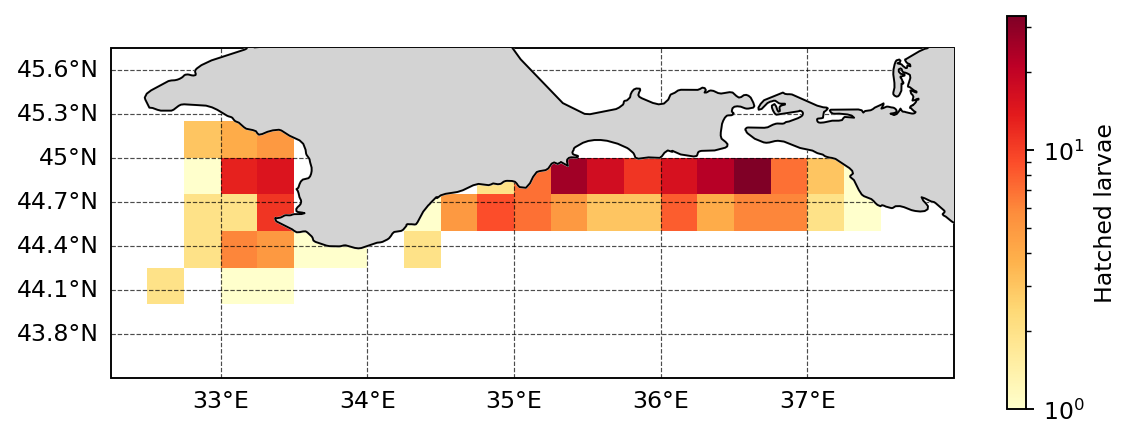

In [9]:
df['time_finish'] = pd.to_datetime(df['time_finish'])
df_ready = df[df['stage'] == 1]
longitudes = df_ready['lon_finish'].values
latitudes = df_ready['lat_finish'].values

lon_bins = np.arange(31.5, 39, 0.25)  
lat_bins = np.arange(43, 46, 0.25) 

counts, lon_edges, lat_edges = np.histogram2d(longitudes, latitudes, bins=[lon_bins, lat_bins])

counts = counts.T

fig, axs = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
bbox = [32.25, 38, 43.5, 45.75]
ax = make_map(axs, bbox)

mesh = ax.pcolormesh(lon_edges, lat_edges, counts, cmap='YlOrRd', norm=colors.LogNorm(), shading='auto')

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.5)
cbar.set_label('Hatched larvae')
plt.show()


### Travelled distance hist

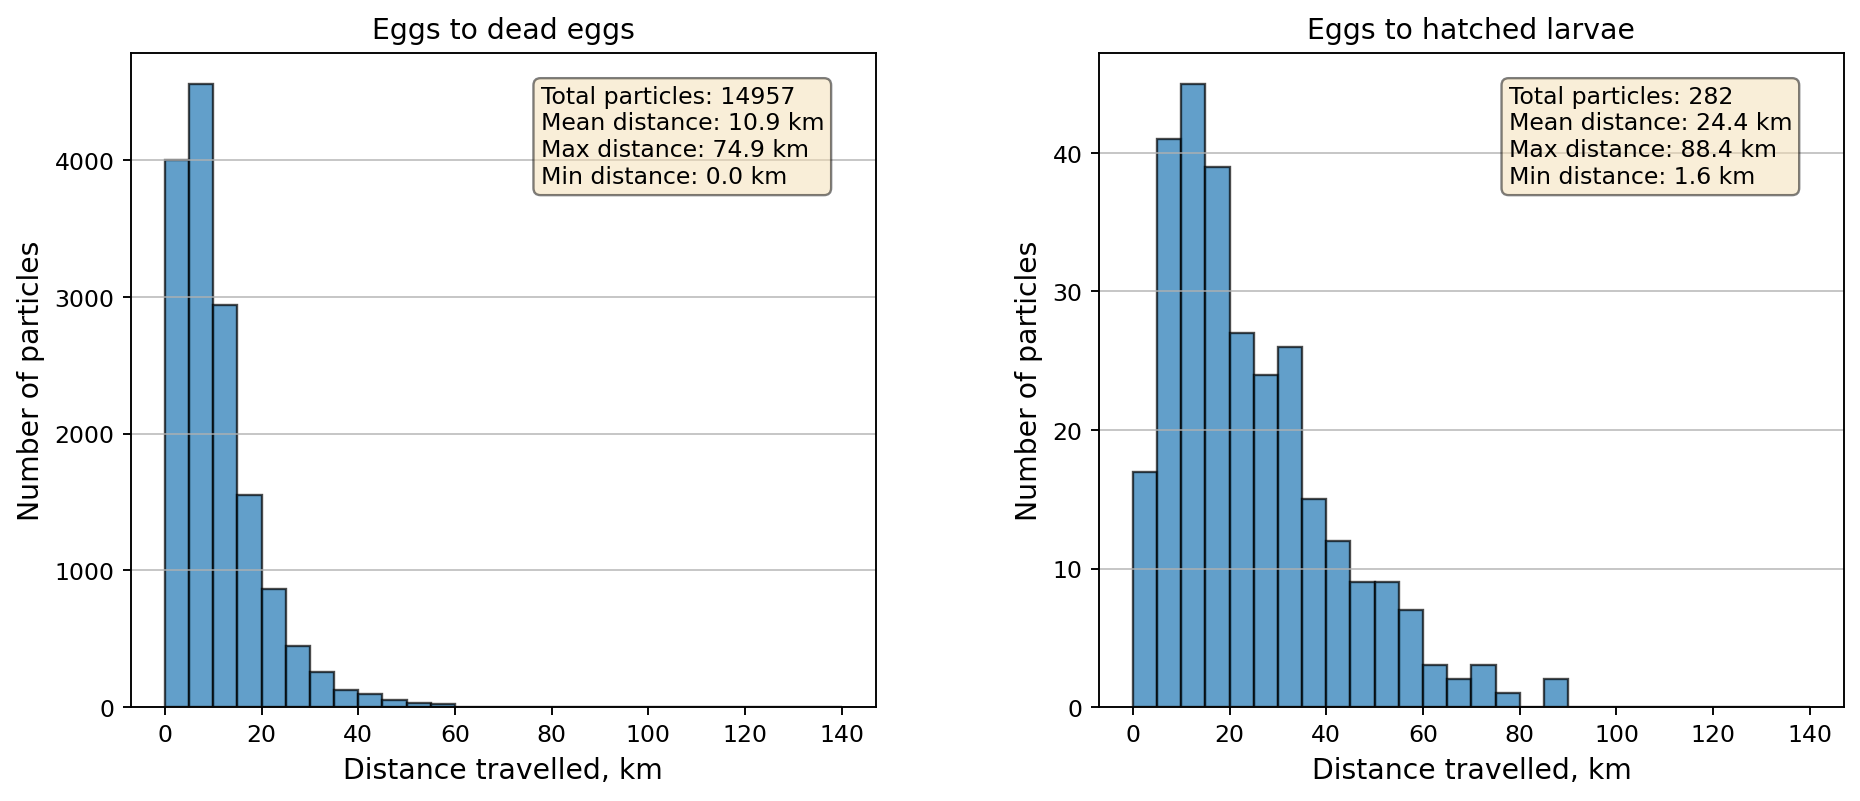

In [10]:
def fast_haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    # Convert to radians
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)
    
    # Differences
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    # Haversine formula
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

df['distance_km'] = fast_haversine(
    df['lat_start'].values, 
    df['lon_start'].values, 
    df['lat_finish'].values, 
    df['lon_finish'].values
)

dead_df = df[df['stage'] < 1]
live_df = df[df['stage'] == 1]


fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)
names = ['Eggs to dead eggs', 'Eggs to hatched larvae']
for i, target_df in enumerate([dead_df, live_df]):
    bins = np.arange(0, 140 + 1, 5)
    ax[i].hist(target_df['distance_km'], bins=bins, edgecolor='black', alpha=0.7)
    ax[i].set_xlabel('Distance travelled, km', fontsize=12)
    ax[i].set_ylabel('Number of particles', fontsize=12)
    ax[i].set_title(names[i])

    stats_text = (
                f"Total particles: {len(target_df)}\n"
                f"Mean distance: {target_df['distance_km'].mean():.1f} km\n"
                f"Max distance: {target_df['distance_km'].max():.1f} km\n"
                f"Min distance: {target_df['distance_km'].min():.1f} km"
                )

    ax[i].text(0.55, 0.95, stats_text, transform=ax[i].transAxes, 
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontsize=10)
    ax[i].grid(axis='y', alpha=0.75)
